# RL

Temperature Perturbation

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC, DDPG
import utils

data_rl_2 = {
    'timestep': [],
    'dxdt' : [],
    'delE':[]
}
experiment_name = "sac_evalcb"
experiment_folder = os.path.join("experiments",experiment_name)
best_model_folder = os.path.join(experiment_folder, "model" )
best_model_path = os.path.join(best_model_folder, "best_model.zip")

if 'ppo' in experiment_name:
    loaded_model = PPO.load(best_model_path)
elif 'sac' in experiment_name:
    loaded_model = SAC.load(best_model_path)
elif 'ddpg' in experiment_name:
    loaded_model = DDPG.load(best_model_path)

def run_rl_temp_simulation(start_hour, end_hour, runs=10):
    rl_activs = []
    for i in range(runs):
        # Initial conditions
        X0 = config.X0  # CDW g/L 
        S0 = config.S0 # mol/L
        E0 = config.E0 # U/L 

        # Process conditions
        T = config.INIT_TEMPRATURE #'C 
        T_opt = config.OPTIMUM_TEMPERATURE #'C
        A = config.INIT_AGITATION # RPM

        MuE_opt = config.MUE_OPT    # U/CDW g
        mu_max = config.MU_MAX   # /h
        del_t = config.DEL_T # hours ie. 36 seconds
        t_end = config.T_END
        total_sim_steps = int(t_end/del_t)
        tvec = [del_t + i * del_t for i in range(total_sim_steps)]
        ns = len(tvec)

        # Substrate addition calculations
        tank_capacity = config.TANK_CAPACITY # L
        substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
        max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
        substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
        media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
        media_transfer_step = int(media_transfer_gap/del_t)
        substrate_concentration = S0
        sub_in_tank_moles = S0 * substrate_in_tank_liters # mol
        flow_rates= []
        # external media tank configurations
        ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
        substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

        # X S E delE delX, muE
        D = np.zeros((ns+1, 6))
        D[0][0] = X0
        D[0][1] = substrate_concentration
        D[0][2] = E0
        for i in range(ns):
            X = D[i][0]
            S = D[i][1]
            E = D[i][2]

            if i == (start_hour/del_t):
                T = 38
            elif i >= (end_hour/del_t):
                T = T_opt

            temp_dep = 1 * math.exp(-((T - T_opt) ** 2) / (5 ** 2))

            MuX = utils.cell_growth_rate_test(S,mu_max)
            # new cells that are generated

            MuX = MuX * temp_dep

            dXdt = utils.cells_produced(X, MuX)

            # SUbstrate consumption
            dSdt = utils.substrate_consumed(dXdt)

            # Find change in cells 
            delX = dXdt * del_t
            # Update cells
            D[i+1][0] = X + delX
            
            # Find change in substrate
            delS = dSdt * del_t

            # # Update substrate
            

            # if i > (2/del_t) and i < (4/del_t):
            #     pass
            # else:
            if substrate_in_tank_liters < max_substrate_limit_liters:
                if i%(media_transfer_step) == 0 and i != 0: 
                    model_input = np.array([i, E, X])
                    action = loaded_model.predict(model_input, deterministic=False)
                    substrate_action = action[0][0]
                    flow_rates.append(substrate_action)
                    if True:
                        # get substrate concentraion for current timestep
                        substrate_concentration = S
                        sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                        # Add substrate and calculate new concentraion
                        substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                        sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                        substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                        S = substrate_concentration
                else:
                    flow_rates.append(0)
            else:
                flow_rates.append(0)
            # Check if substrate is less than or close to 0
            if S + delS < 0.000001:
                D[i+1][1] = 0
            else:
                D[i+1][1] = S + delS

            # Enzyme determination 
            sub_cell_ratio = (S/X) * 1e6

            weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO*1e6)
            MuE = MuE_opt * weibull

            if dXdt == 0:
                MuE = 0

            # new enzyme from fresh cells
            delE = MuE * X * del_t

            # Update enzyme variable
            D[i+1][2] = E + delE

            # terminate if tank capacity is full and cells start dying
            if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
                break
            
        X = D[:,0][0:i]
        S = D[:,1][0:i]
        E = D[:,2][0:i]
        S_C_R = (S/X)
        rl_activs.append(E[-1])

    return rl_activs

# RL 
Pump Perturbation

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC, DDPG
import utils

data_rl_2 = {
    'timestep': [],
    'dxdt' : [],
    'delE':[]
}
experiment_name = "sac_evalcb"
experiment_folder = os.path.join("experiments",experiment_name)
best_model_folder = os.path.join(experiment_folder, "model" )
best_model_path = os.path.join(best_model_folder, "best_model.zip")

if 'ppo' in experiment_name:
    loaded_model = PPO.load(best_model_path)
elif 'sac' in experiment_name:
    loaded_model = SAC.load(best_model_path)
elif 'ddpg' in experiment_name:
    loaded_model = DDPG.load(best_model_path)

def run_rl_pump_simulation(start_hour, end_hour, runs=10):
    rl_activs = []
    for _ in range(runs):
        
        # Initial conditions
        X0 = config.X0  # CDW g/L 
        S0 = config.S0 # mol/L
        E0 = config.E0 # U/L 

        # Process conditions
        T = config.INIT_TEMPRATURE #'C 
        T_opt = config.OPTIMUM_TEMPERATURE #'C
        A = config.INIT_AGITATION # RPM

        MuE_opt = config.MUE_OPT    # U/CDW g
        mu_max = config.MU_MAX   # /h
        del_t = config.DEL_T # hours ie. 36 seconds
        t_end = config.T_END
        total_sim_steps = int(t_end/del_t)
        tvec = [del_t + i * del_t for i in range(total_sim_steps)]
        ns = len(tvec)

        # Substrate addition calculations
        tank_capacity = config.TANK_CAPACITY # L
        substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
        max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
        substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
        media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
        media_transfer_step = int(media_transfer_gap/del_t)
        substrate_concentration = S0
        sub_in_tank_moles = S0 * substrate_in_tank_liters # mol
        flow_rates= []
        # external media tank configurations
        ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
        substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

        # X S E delE delX, muE
        D = np.zeros((ns+1, 6))
        D[0][0] = X0
        D[0][1] = substrate_concentration
        D[0][2] = E0
        for i in range(ns):
            X = D[i][0]
            S = D[i][1]
            E = D[i][2]

            MuX = utils.cell_growth_rate_test(S,mu_max)
            # new cells that are generated

            dXdt = utils.cells_produced(X, MuX)

            # SUbstrate consumption
            dSdt = utils.substrate_consumed(dXdt)

            # Find change in cells 
            delX = dXdt * del_t
            # Update cells
            D[i+1][0] = X + delX
            
            # Find change in substrate
            delS = dSdt * del_t

            # # Update substrate

            if i > (start_hour/del_t) and i < (end_hour/del_t):
                pass
            else:
                if substrate_in_tank_liters < max_substrate_limit_liters:
                    if i%(media_transfer_step) == 0 and i != 0: 
                        model_input = np.array([i, E, X])
                        action = loaded_model.predict(model_input, deterministic=False)
                        substrate_action = action[0][0]
                        if True:
                            # get substrate concentraion for current timestep
                            substrate_concentration = S
                            sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                            # Add substrate and calculate new concentraion
                            substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                            sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                            substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                            S = substrate_concentration
                    
            # Check if substrate is less than or close to 0
            if S + delS < 0.000001:
                D[i+1][1] = 0
            else:
                D[i+1][1] = S + delS

            # Enzyme determination 
            sub_cell_ratio = (S/X) * 1e6

            weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO*1e6)
            MuE = MuE_opt * weibull

            if dXdt == 0:
                MuE = 0

            # new enzyme from fresh cells
            delE = MuE * X * del_t

            # Update enzyme variable
            D[i+1][2] = E + delE

            # terminate if tank capacity is full and cells start dying
            if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
                break
            
        X = D[:,0][0:i]
        S = D[:,1][0:i]
        E = D[:,2][0:i]
        S_C_R = (S/X)
        rl_activs.append(E[-1])

    return rl_activs

# Traditional Controller 

Temperature Perturbation

In [18]:
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import numpy as np


tc_scr = []
runs = 10

def run_tc_temp_simulation(start_hour, end_hour, runs=10):
    tc_e_activities = []
    for i in range(runs):
        start_flow_volume = 0.0008892908583470567
        feed_interval = 0.15295954782159268
        ramp_factor = 0.05983974644980618
        initial_volume = start_flow_volume
        flow_volume = initial_volume
        ramp_rate = ramp_factor
        # Initial conditions
        X0 = config.X0  # CDW g/L 
        S0 = config.S0 # mol/L
        E0 = config.E0 # U/L 

        # Process conditions
        T = config.INIT_TEMPRATURE #'C 
        T_opt = config.OPTIMUM_TEMPERATURE #'C
        A = config.INIT_AGITATION # RPM

        # model parameters
        Ks = config.KS    # mol/L
        Yxs =  config.YXS  # CDW g/mol
        MuE_opt = config.MUE_OPT    # U/CDW g
        mu_max =  config.MU_MAX  # /h
        del_t = config.DEL_T # hours ie. 36 seconds
        t_end = config.T_END
        total_sim_steps = int(t_end/del_t)
        tvec = [del_t + i * del_t for i in range(total_sim_steps)]
        ns = len(tvec)
        kl = config.KL # mol/L
        cell_death_timer = config.CELL_DEATH_TIMER
        cell_death_time = config.CELL_DEATH_TIME
        substrate_actions = []
        # Substrate addition calculations
        tank_capacity = config.TANK_CAPACITY # L
        substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
        max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
        substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
        media_transfer_gap =  feed_interval # Hours this is after 10 steps ie. 6 minutes
        media_transfer_step = int(media_transfer_gap/del_t)
        substrate_concentration = S0
        sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

        # external media tank configurations
        ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
        substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

        # X S E delE delX, muE
        D = np.zeros((ns+1, 6))
        D[0][0] = X0
        D[0][1] = substrate_concentration
        D[0][2] = E0

        for i in range(ns):
            X = D[i][0]
            S = D[i][1]
            E = D[i][2]

            if i == (start_hour/del_t):
                T = 38
            elif i >= (end_hour/del_t):
                T = T_opt

            temp_dep = 1 * math.exp(-((T - T_opt) ** 2) / (5 ** 2))

            MuX = utils.cell_growth_rate(S)

            MuX = MuX * temp_dep
            # new cells that are generated
            dXdt = utils.cells_produced(X, MuX)

            # SUbstrate consumption
            dSdt = utils.substrate_consumed(dXdt)

            # Find change in cells 
            delX = dXdt * del_t
            # Update cells
            D[i+1][0] = X + delX

            # Find change in substrate
            delS = dSdt * del_t

            # if i > (6/del_t) and i < (8/del_t):
            #     pass
            # else:
            # # Update substrate
            if substrate_in_tank_liters < max_substrate_limit_liters:
                if i%(media_transfer_step) == 0 and i != 0:
                    flow_volume *= math.exp(ramp_rate)
                    substrate_action = flow_volume
                    substrate_actions.append(substrate_action)
                    if True:
                        # get substrate concentraion for current timestep
                        substrate_concentration = S
                        sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                        # Add substrate and calculate new concentraion
                        substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                        sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                        substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                        S = substrate_concentration


            # Check if substrate is less than or close to 0
            if S + delS < 0.000001:
                D[i+1][1] = 0
            else:
                D[i+1][1] = S + delS

            # Enzyme determination 
            sub_cell_ratio = (S/X) * 1e6

            weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO*1e6)
            MuE = MuE_opt * weibull

            if dXdt == 0:
                MuE = 0

            # new enzyme from fresh cells
            delE = MuE * X * del_t
            
            # Update enzyme variable
            D[i+1][2] = E + delE

            # terminate if tank capacity is full and cells start dying
            if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
                break
            
        X = D[:,0][0:i]
        S = D[:,1][0:i]
        E = D[:,2][0:i]
        S_C_R = (S/X)
        tc_e_activities.append(E[-1])



    return(tc_e_activities)


# Traditional Controller 
Pump Perturbations

In [19]:
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import numpy as np

tc_scr = []
runs = 10

def run_tc_pump_simulation(start_hour, end_hour, runs=10):
    tc_e_activities = []
    for i in range(runs):
        start_flow_volume = 0.0008892908583470567
        feed_interval = 0.15295954782159268
        ramp_factor = 0.05983974644980618
        initial_volume = start_flow_volume
        flow_volume = initial_volume
        ramp_rate = ramp_factor
        # Initial conditions
        X0 = config.X0  # CDW g/L 
        S0 = config.S0 # mol/L
        E0 = config.E0 # U/L 

        # Process conditions
        T = config.INIT_TEMPRATURE #'C 
        T_opt = config.OPTIMUM_TEMPERATURE #'C
        A = config.INIT_AGITATION # RPM

        # model parameters
        Ks = config.KS    # mol/L
        Yxs =  config.YXS  # CDW g/mol
        MuE_opt = config.MUE_OPT    # U/CDW g
        mu_max =  config.MU_MAX  # /h
        del_t = config.DEL_T # hours ie. 36 seconds
        t_end = config.T_END
        total_sim_steps = int(t_end/del_t)
        tvec = [del_t + i * del_t for i in range(total_sim_steps)]
        ns = len(tvec)
        kl = config.KL # mol/L
        cell_death_timer = config.CELL_DEATH_TIMER
        cell_death_time = config.CELL_DEATH_TIME
        substrate_actions = []
        # Substrate addition calculations
        tank_capacity = config.TANK_CAPACITY # L
        substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
        max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
        substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
        media_transfer_gap =  feed_interval # Hours this is after 10 steps ie. 6 minutes
        media_transfer_step = int(media_transfer_gap/del_t)
        substrate_concentration = S0
        sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

        # external media tank configurations
        ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
        substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

        # X S E delE delX, muE
        D = np.zeros((ns+1, 6))
        D[0][0] = X0
        D[0][1] = substrate_concentration
        D[0][2] = E0

        for i in range(ns):
            X = D[i][0]
            S = D[i][1]
            E = D[i][2]

            MuX = utils.cell_growth_rate(S)

            # new cells that are generated
            dXdt = utils.cells_produced(X, MuX)

            # SUbstrate consumption
            dSdt = utils.substrate_consumed(dXdt)

            # Find change in cells 
            delX = dXdt * del_t
            # Update cells
            D[i+1][0] = X + delX

            # Find change in substrate
            delS = dSdt * del_t

            if i > (start_hour/del_t) and i < (end_hour/del_t):
                pass
            else:
            # Update substrate
                if substrate_in_tank_liters < max_substrate_limit_liters:
                    if i%(media_transfer_step) == 0 and i != 0:
                        flow_volume *= math.exp(ramp_rate)
                        substrate_action = flow_volume
                        substrate_actions.append(substrate_action)
                        if True:
                            # get substrate concentraion for current timestep
                            substrate_concentration = S
                            sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                            # Add substrate and calculate new concentraion
                            substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                            sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                            substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                            S = substrate_concentration


            # Check if substrate is less than or close to 0
            if S + delS < 0.000001:
                D[i+1][1] = 0
            else:
                D[i+1][1] = S + delS

            # Enzyme determination 
            sub_cell_ratio = (S/X) * 1e6

            weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO*1e6)
            MuE = MuE_opt * weibull

            if dXdt == 0:
                MuE = 0

            # new enzyme from fresh cells
            delE = MuE * X * del_t
            
            # Update enzyme variable
            D[i+1][2] = E + delE

            # terminate if tank capacity is full and cells start dying
            if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
                break
            
        X = D[:,0][0:i]
        S = D[:,1][0:i]
        E = D[:,2][0:i]
        S_C_R = (S/X)
        tc_e_activities.append(E[-1])



    return(tc_e_activities)


In [20]:
len(run_rl_pump_simulation(start_hour=2, end_hour=4, runs=10))

10

# FIGURES

# Plot for pump perturbation

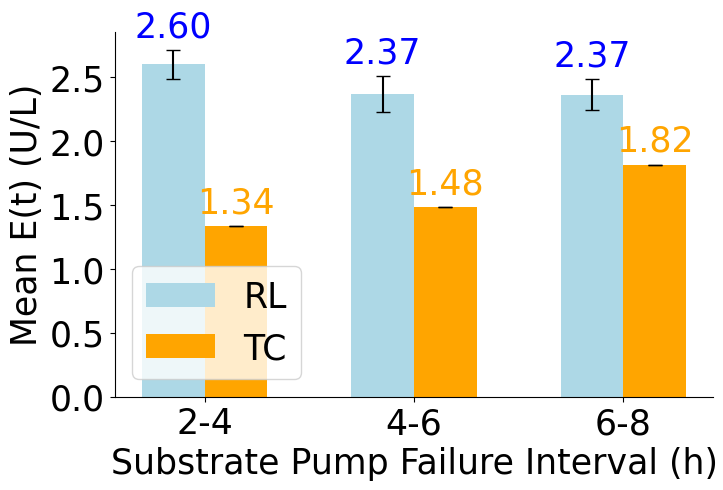

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Example enzyme activity data for both methods
RL_data = {
    '2-4': run_rl_pump_simulation(start_hour=2, end_hour=4),
    '4-6': run_rl_pump_simulation(start_hour=4, end_hour=6),
    '6-8': run_rl_pump_simulation(start_hour=6, end_hour=8)
}

Traditional_data = {
    '2-4': run_tc_pump_simulation(start_hour=2,end_hour=4),
    '4-6': run_tc_pump_simulation(start_hour=4,end_hour=6),
    '6-8': run_tc_pump_simulation(start_hour=6,end_hour=8)
}

# Categories
categories = ['2-4', '4-6', '6-8']

# Calculate means and standard deviations for each category
means_rl = [np.mean(RL_data[cat]) for cat in categories]
std_rl = [np.std(RL_data[cat]) for cat in categories]

means_trad = [np.mean(Traditional_data[cat]) for cat in categories]
std_trad = [np.std(Traditional_data[cat]) for cat in categories]

# Bar width and x positions
bar_width = 0.30
x = np.arange(len(categories))

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 5))

# Plot bars with error bars
bars_rl = ax.bar(x - bar_width/2, means_rl, bar_width, yerr=std_rl, label='RL', color='lightblue', capsize=5)
bars_trad = ax.bar(x + bar_width/2, means_trad, bar_width, yerr=std_trad, label='TC', color='orange', capsize=5)

# Add labels and title with fontsize=20
ax.set_xlabel('Substrate Pump Failure Interval (h)', fontsize=25)
ax.set_ylabel('Mean E(t) (U/L)', fontsize=25)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=25)
ax.legend(fontsize=25)

# Add mean values on top of the bars
for i in range(len(categories)):
    ax.text(x[i] - bar_width/2, means_rl[i] + std_rl[i] + 0.05, f'{means_rl[i]:.2f}', 
            ha='center', va='bottom', fontsize=25, color='blue')
    ax.text(x[i] + bar_width/2, means_trad[i] + std_trad[i] + 0.05, f'{means_trad[i]:.2f}', 
            ha='center', va='bottom', fontsize=25, color='orange')

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Set global font to Times New Roman
plt.rcParams["font.family"] = "sans-serif"
# Display the plot
plt.tight_layout()
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

figure_path = os.path.join('figures', 'figure9', 'figure9a.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=300)
plt.show()



# Temperature Perturbation

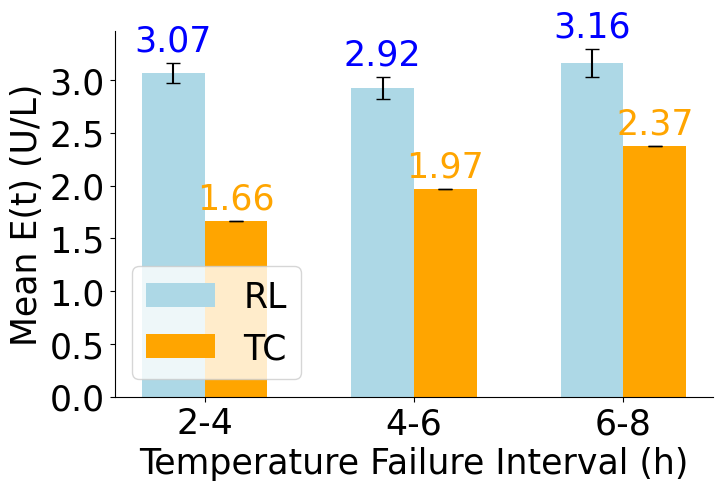

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Example enzyme activity data for both methods
RL_data = {
    '2-4': run_rl_temp_simulation(start_hour=2, end_hour=4),
    '4-6': run_rl_temp_simulation(start_hour=4, end_hour=6),
    '6-8': run_rl_temp_simulation(start_hour=6, end_hour=8)
}

Traditional_data = {
    '2-4': run_tc_temp_simulation(start_hour=2,end_hour=4),
    '4-6': run_tc_temp_simulation(start_hour=4,end_hour=6),
    '6-8': run_tc_temp_simulation(start_hour=6,end_hour=8)
}

# Categories
categories = ['2-4', '4-6', '6-8']

# Calculate means and standard deviations for each category
means_rl = [np.mean(RL_data[cat]) for cat in categories]
std_rl = [np.std(RL_data[cat]) for cat in categories]

means_trad = [np.mean(Traditional_data[cat]) for cat in categories]
std_trad = [np.std(Traditional_data[cat]) for cat in categories]

# Bar width and x positions
bar_width = 0.30
x = np.arange(len(categories))

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 5))
# Set global font to Times New Roman
plt.rcParams["font.family"] = "sans-serif"
# Plot bars with error bars
bars_rl = ax.bar(x - bar_width/2, means_rl, bar_width, yerr=std_rl, label='RL', color='lightblue', capsize=5)
bars_trad = ax.bar(x + bar_width/2, means_trad, bar_width, yerr=std_trad, label='TC', color='orange', capsize=5)

# Add labels and title with fontsize=20
ax.set_xlabel('Temperature Failure Interval (h)', fontsize=25)
ax.set_ylabel('Mean E(t) (U/L)', fontsize=25)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=25)
ax.legend(fontsize=25)

# Add mean values on top of the bars
for i in range(len(categories)):
    ax.text(x[i] - bar_width/2, means_rl[i] + std_rl[i] + 0.05, f'{means_rl[i]:.2f}', 
            ha='center', va='bottom', fontsize=25, color='blue')
    ax.text(x[i] + bar_width/2, means_trad[i] + std_trad[i] + 0.05, f'{means_trad[i]:.2f}', 
            ha='center', va='bottom', fontsize=25, color='orange')

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Display the plot
plt.tight_layout()
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
figure_path = os.path.join('figures', 'figure9', 'figure9b.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=300)
plt.show()



# Figure 9c, d
Example of pump failure

 -----------------------------------------------------------------------
 ----------------------------  Results  --------------------------------
 MAX ENZYME ACTIVITY :  2.6550771892771743


<Figure size 700x500 with 0 Axes>

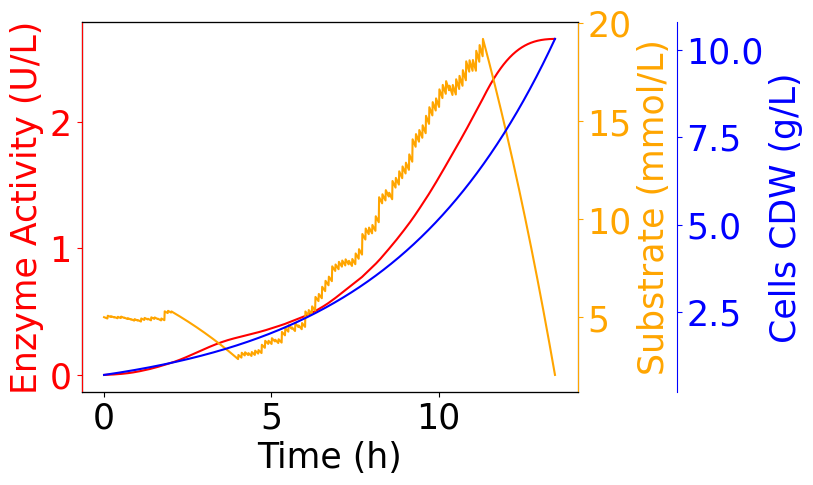

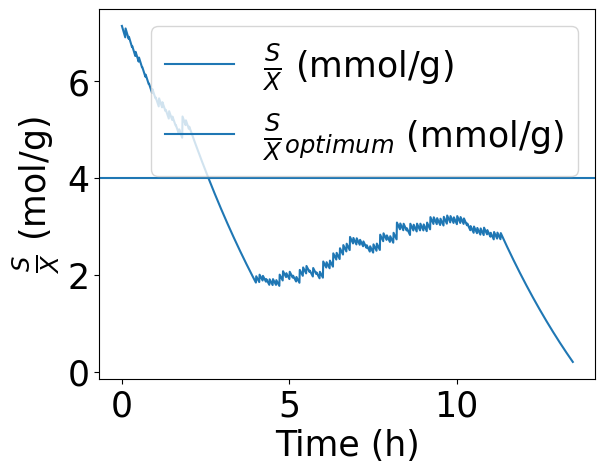

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC, DDPG
import utils


experiment_name = "sac_evalcb"
experiment_folder = os.path.join("experiments",experiment_name)
best_model_folder = os.path.join(experiment_folder, "model" )
best_model_path = os.path.join(best_model_folder, "best_model.zip")

if 'ppo' in experiment_name:
    loaded_model = PPO.load(best_model_path)
elif 'sac' in experiment_name:
    loaded_model = SAC.load(best_model_path)
elif 'ddpg' in experiment_name:
    loaded_model = DDPG.load(best_model_path)

        
# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol
flow_rates= []
# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0
for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    MuX = utils.cell_growth_rate_test(S,mu_max)
    # new cells that are generated

    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate

    if i > (2/del_t) and i < (4/del_t):
        pass
    else:
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0: 
                model_input = np.array([i, E, X])
                action = loaded_model.predict(model_input, deterministic=False)
                substrate_action = action[0][0]
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration
            
    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO*1e6)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t

    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break
    
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = S/X

max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)

'''
================================================================================================================================================
                                                    Plotting      
================================================================================================================================================
'''

print(" -----------------------------------------------------------------------")
print(" ----------------------------  Results  --------------------------------")
print(" MAX ENZYME ACTIVITY : ", max(D[:,2]))

# First figure
plt.figure(figsize=(7, 5))
fig, ax1 = plt.subplots()
# Set global font to Times New Roman
plt.rcParams["font.family"] = "sans-serif"
ax1.plot(tvec[0:i], E, color="red", label="Enzyme Activity U/L")
ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S*1e3, color="orange", label="Substrate mmol/L")
ax3 = ax1.twinx()
ax3.plot(tvec[0:i], X, color="blue", label="Cells CDW g/L")
ax3.spines['right'].set_position(('axes', 1.20))

# Set axis labels with increased fontsize
ax1.set_ylabel("Enzyme Activity (U/L)", color="red", fontsize=25)
ax1.set_xlabel("Time (h)", fontsize=25)
ax2.set_ylabel("Substrate (mmol/L)", color="orange", fontsize=25)
ax3.set_ylabel("Cells CDW (g/L)", color="blue", fontsize=25)

# Tick parameters with increased fontsize
ax1.tick_params(axis='y', colors="red", labelsize=25)
ax2.tick_params(axis='y', colors="orange", labelsize=25)
ax3.tick_params(axis='y', colors="blue", labelsize=25)
ax1.tick_params(axis='x', labelsize=25)

# Customize spines
ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")

# Save the figure as PDF
figure_path = os.path.join('figures', 'figure9', 'figure9c.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=300)

plt.show()

# Second figure
plt.figure()
plt.plot(tvec[:len(S_C_R)], S_C_R*1e3, label=r"$\frac{S}{X}$ (mmol/g)")

# Set axis labels and legend fontsize
plt.xlabel("Time (h)", fontsize=25)
plt.ylabel(r"$\frac{S}{X}$ (mol/g)", fontsize=25)
plt.axhline(y=config.OPT_SUB_CELL_RATIO*1e3, label=r"$\frac{S}{X}_{optimum}$ (mmol/g)")
plt.tick_params(axis='both', labelsize=25)
plt.legend(fontsize=25)
figure_path = os.path.join('figures', 'figure9', 'figure9d.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=300)
plt.show()




# Figure9e

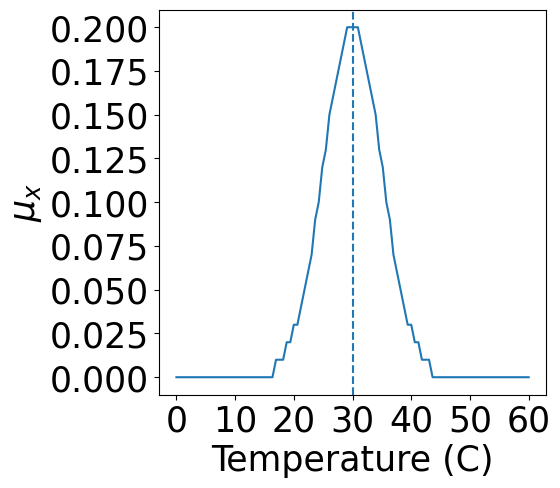

In [24]:
import numpy as np
import config
import numpy as np
import matplotlib.pyplot as plt


temperatures = np.linspace(0, 60, 100)
mux = []

for i in temperatures:
    x = 0.2 * np.exp(-((i - 30) ** 2) / (7 ** 2))
    mux.append(round(x,2))
# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"
plt.figure(figsize=(5,5))
plt.plot(temperatures, mux)
plt.xlabel("Temperature (C)", fontsize=25)
plt.ylabel(r"$\mu_x$",fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.axvline(x=30, linestyle='--')




figure_path = os.path.join('figures', 'figure9', 'figure9e.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=300)